In [ ]:
# 1. SETUP, DRIVE & INSTALLATION
from google.colab import drive
drive.mount('/content/drive')
!unzip -q -o "/content/drive/MyDrive/Colab Notebooks/data.zip" -d "/content/"
print("Đã giải nén và tự động cập nhật toàn bộ data!")
!pip install segmentation-models-pytorch gradio

Mounted at /content/drive
Đã giải nén và tự động cập nhật toàn bộ data!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.7 MB/s eta 0:00:00


In [ ]:
# CELL 2: DATASET
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
TRAIN_IMG_DIR = "/content/train"
TRAIN_MASK_DIR = "/content/train_gt"
IMG_SIZE = 352
BATCH_SIZE = 8
EPOCHS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks"
os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, "best_polyp_model.pth")
print(f"[*] Thiết bị đang dùng: {DEVICE}")
print(f"[*] Model tốt nhất sẽ được lưu vĩnh viễn tại: {MODEL_SAVE_PATH}")
class PolypDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=352):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, img_name.rsplit('.', 1)[0] + ".png")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = (mask > 0).astype(np.float32)
        image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        return image, mask

[*] Thiết bị đang dùng: cuda
[*] Model tốt nhất sẽ được lưu vĩnh viễn tại: /content/drive/MyDrive/Colab Notebooks/best_polyp_model.pth


In [ ]:
# QUANTITATIVE EVALUATION
def calculate_all_metrics(pred_mask, true_mask):
    pred = (pred_mask > 0.5).float()
    true = (true_mask > 0.5).float()
    tp = torch.sum(pred * true)
    fp = torch.sum(pred * (1 - true))
    fn = torch.sum((1 - pred) * true)
    epsilon = 1e-7
    dice = (2.0 * tp + epsilon) / (2.0 * tp + fp + fn + epsilon)
    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    precision = (tp + epsilon) / (tp + fp + epsilon)
    recall = (tp + epsilon) / (tp + fn + epsilon)

    return dice.item(), iou.item(), precision.item(), recall.item()

In [ ]:
# CELL 4.1: TRAINING LOOP (CẬP NHẬT TỰ ĐỘNG LƯU DRIVE)
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)
dataset = PolypDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
criterion_bce = torch.nn.BCEWithLogitsLoss()
criterion_dice = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
def criterion(pred, target):
    return 0.5 * criterion_bce(pred, target) + 0.5 * criterion_dice(pred, target)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
history = {'loss': [], 'dice': [], 'iou': [], 'precision': [], 'recall': []}
best_dice = 0.0
best_epoch_idx = 0
print(f"[*] Bắt đầu Training trong {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    model.eval()
    m_dice, m_iou, m_pre, m_rec = 0, 0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = torch.sigmoid(model(x))
            d, i, p, r = calculate_all_metrics(preds, y)
            m_dice += d
            m_iou += i
            m_pre += p
            m_rec += r
    num_batches = len(val_loader)
    curr_loss = total_loss / len(train_loader)
    curr_dice = m_dice / num_batches
    history['loss'].append(curr_loss)
    history['dice'].append(curr_dice)
    history['iou'].append(m_iou / num_batches)
    history['precision'].append(m_pre / num_batches)
    history['recall'].append(m_rec / num_batches)
    scheduler.step(curr_dice)
    print(f"Epoch {epoch+1}/{EPOCHS}: Loss={curr_loss:.4f}, Dice={curr_dice:.4f}", end="")
    if curr_dice > best_dice:
        best_dice = curr_dice
        best_epoch_idx = epoch
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(" -> [Đã lưu Best Model vào Drive]")
    else:
        print()
print("\n[*] TRAINING HOÀN TẤT!")
print(f"[*] Model tốt nhất ở Epoch {best_epoch_idx + 1} với Dice Score: {best_dice:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[*] Bắt đầu Training trong 50 epochs...
Epoch 1/50: Loss=0.6558, Dice=0.8118 -> [Đã lưu Best Model vào Drive]
Epoch 2/50: Loss=0.4887, Dice=0.8515 -> [Đã lưu Best Model vào Drive]
Epoch 3/50: Loss=0.4111, Dice=0.8772 -> [Đã lưu Best Model vào Drive]
Epoch 4/50: Loss=0.3241, Dice=0.8865 -> [Đã lưu Best Model vào Drive]
Epoch 5/50: Loss=0.2529, Dice=0.8976 -> [Đã lưu Best Model vào Drive]
Epoch 6/50: Loss=0.1931, Dice=0.9028 -> [Đã lưu Best Model vào Drive]
Epoch 7/50: Loss=0.1632, Dice=0.8749
Epoch 8/50: Loss=0.1273, Dice=0.8811
Epoch 9/50: Loss=0.1021, Dice=0.8854
Epoch 10/50: Loss=0.0838, Dice=0.9072 -> [Đã lưu Best Model vào Drive]
Epoch 11/50: Loss=0.0687, Dice=0.9012
Epoch 12/50: Loss=0.0576, Dice=0.9102 -> [Đã lưu Best Model vào Drive]
Epoch 13/50: Loss=0.0505, Dice=0.9139 -> [Đã lưu Best Model vào Drive]
Epoch 14/50: Loss=0.0437, Dice=0.9175 -> [Đã lưu Best Model vào Drive]
Epoch 15/50: Loss=0.0577, Dice=0.8431
Epoch 16/50: Loss=0.0578, Dice=0.8884
Epoch 17/50: Loss=0.0448, Dice=

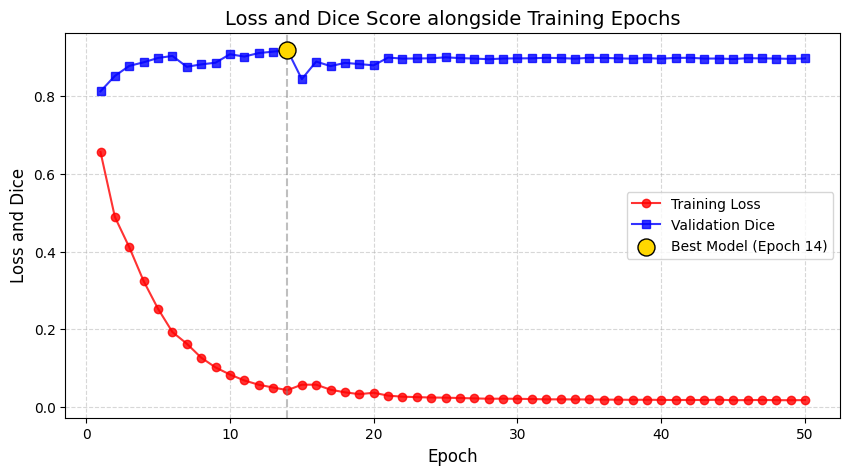

In [ ]:
# CELL 4.2: TRAINING PROGRESS
plt.figure(figsize=(10, 5))
epochs_range = range(1, len(history['loss']) + 1)
plt.plot(epochs_range, history['loss'], 'r-o', label='Training Loss', alpha=0.8)
plt.plot(epochs_range, history['dice'], 'b-s', label='Validation Dice', alpha=0.8)
best_epoch_num = best_epoch_idx + 1
plt.scatter(best_epoch_num, history['dice'][best_epoch_idx], color='gold', s=150, edgecolors='black', zorder=5, label=f'Best Model (Epoch {best_epoch_num})')
plt.axvline(x=best_epoch_num, color='gray', linestyle='--', alpha=0.5)
plt.title('Loss and Dice Score alongside Training Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss and Dice', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# CELL 4.3: QUANTITATIVE EVALUATION
import pandas as pd
print("\n" + "="*50)
print(f"--- 4.3 QUANTITATIVE EVALUATION (AT BEST EPOCH {best_epoch_idx + 1}) ---")
print("="*50)
report_data = {
    "Metric": ["Dice Score", "IoU (Jaccard)", "Precision", "Recall (Sensitivity)"],
    "Value": [
        history['dice'][best_epoch_idx],
        history['iou'][best_epoch_idx],
        history['precision'][best_epoch_idx],
        history['recall'][best_epoch_idx]]}
df_report = pd.DataFrame(report_data)
print(df_report.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))
print("="*50)


--- 4.3 QUANTITATIVE EVALUATION (AT BEST EPOCH 14) ---
              Metric  Value
          Dice Score 0.9175
       IoU (Jaccard) 0.8497
           Precision 0.9417
Recall (Sensitivity) 0.8982


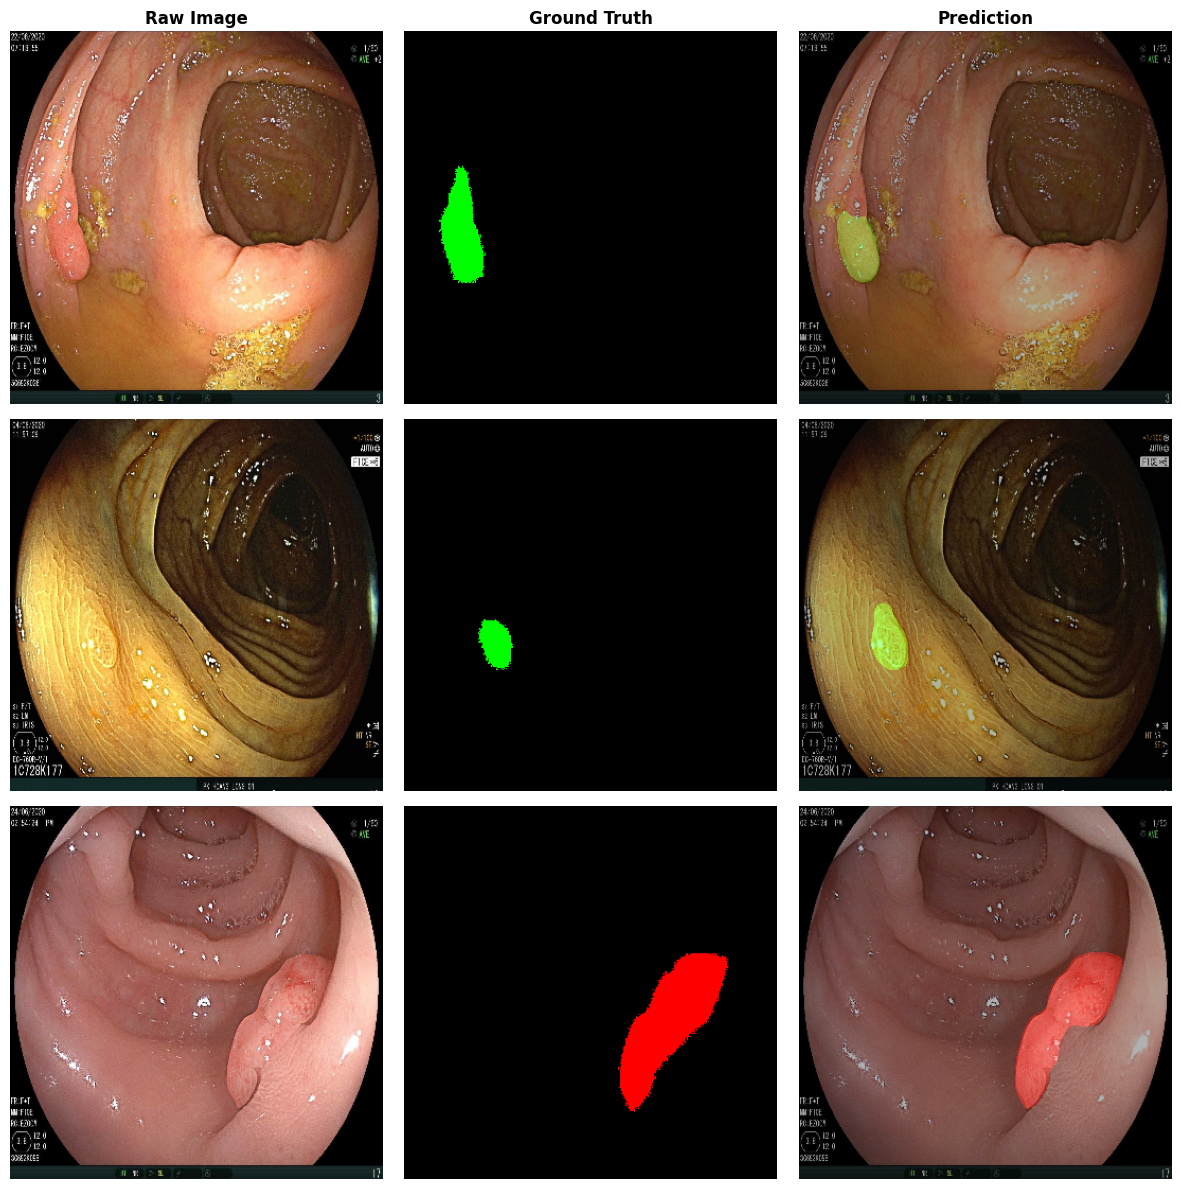

In [ ]:
# CELL 4.4: VISUALIZATION
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import os
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
cols = ['Raw Image', 'Ground Truth', 'Prediction']
for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=12, fontweight='bold')
for i in range(3):
    img_t, msk_t = val_ds[i]
    raw_img_rgb = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    h, w = raw_img_rgb.shape[:2]
    total_area = h * w
    gt_mask_np = msk_t.squeeze().cpu().numpy()
    gt_ratio = np.sum(gt_mask_np) / total_area
    gt_final_img = np.zeros_like(raw_img_rgb)
    if gt_ratio > 0.04:
        gt_final_img[gt_mask_np == 1] = [255, 0, 0]
    elif gt_ratio > 0:
        gt_final_img[gt_mask_np == 1] = [0, 255, 0]
    with torch.no_grad():
        pred_mask_np = (torch.sigmoid(model(img_t.unsqueeze(0).to(DEVICE))) > 0.5).cpu().numpy().squeeze()
    pred_ratio = np.sum(pred_mask_np) / total_area
    color_mask_pred = np.zeros_like(raw_img_rgb)
    if pred_ratio > 0.04:
        color_mask_pred[pred_mask_np == 1] = [255, 0, 0]
    elif pred_ratio > 0:
        color_mask_pred[pred_mask_np == 1] = [0, 255, 0]
    overlay_pred = cv2.addWeighted(raw_img_rgb, 0.7, color_mask_pred, 0.3, 0)
    axes[i,0].imshow(raw_img_rgb)
    axes[i,0].axis('off')
    axes[i,1].imshow(gt_final_img)
    axes[i,1].axis('off')
    axes[i,2].imshow(overlay_pred)
    axes[i,2].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# CELL 5: App
!pip install segmentation-models-pytorch gradio
import os
import cv2
import torch
import numpy as np
import gradio as gr
import segmentation_models_pytorch as smp
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 352
MODEL_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/best_polyp_model.pth"
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(DEVICE)
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
    model.eval()
    print(f"[*] Đã nạp thành công bộ não AI từ: {MODEL_SAVE_PATH}")
else:
    print(f"[!] CẢNH BÁO: Không tìm thấy file {MODEL_SAVE_PATH}. Hãy kiểm tra lại đường dẫn!")
def predict_polyp(input_img):
    if input_img is None: return None
    ori_h, ori_w = input_img.shape[:2]
    img = cv2.resize(input_img, (IMG_SIZE, IMG_SIZE))
    img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE) / 255.0
    with torch.no_grad():
        output = model(img_tensor)
        mask = (torch.sigmoid(output).squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    mask_resized = cv2.resize(mask, (ori_w, ori_h))
    color_mask = np.zeros_like(input_img)
    polyp_area = np.sum(mask_resized)
    total_area = ori_h * ori_w
    if polyp_area > (total_area * 0.04):
        color_mask[mask_resized == 1] = [255, 0, 0]
    else:
        color_mask[mask_resized == 1] = [0, 255, 0]
    result = cv2.addWeighted(input_img, 0.7, color_mask, 0.3, 0)
    return result
with gr.Blocks(title="Polyp Segmentation System") as demo:
    gr.Markdown("<h2 style='text-align: center;'> Polyp Segmentation and Risk Assessment System </h2>")
    gr.Markdown("<p style='text-align: center;'> Risk of developing colorectal cancer: Red - High | Green - Low </p>")
    with gr.Row():
        with gr.Column():
            in_img = gr.Image(label="Input")
            btn_submit = gr.Button("Segment", variant="primary")
        with gr.Column():
            out_img = gr.Image(label="Result")
            btn_clear = gr.Button("Clear result")
    btn_submit.click(fn=predict_polyp, inputs=in_img, outputs=out_img)
    btn_clear.click(fn=lambda: (None, None), inputs=None, outputs=[in_img, out_img])
demo.launch(share=True, debug=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00
Mounted at /content/drive
[*] Đã nạp thành công bộ não AI từ: /content/drive/MyDrive/Colab Notebooks/best_polyp_model.pth
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6df557847919040f10.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
